<a href="https://colab.research.google.com/github/AichaELMouta/GiveMeSomeCreditClassification/blob/main/CreditClassificationML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
creditdata = pd.read_csv('cs-training.csv')

In [6]:
creditdata.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
creditdata.columns


Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

Understanding Columns:
1.  SeriousDlqin2yrs
2.  RevolvingUtilizationOfUnsecuredLines
1.  age
2.  NumberOfTime30-59DaysPastDueNotWorse
1.  DebtRatio
2.  MonthlyIncome
1.  NumberOfOpenCreditLinesAndLoans
2.  NumberOfTimes90DaysLate
1.  NumberRealEstateLoansOrLines
2.  NumberOfTime60-89DaysPastDueNotWorse
1.  NumberOfDependents


















In [8]:
creditdata.shape

(150000, 12)

In [9]:
creditdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [10]:
creditdata[creditdata.duplicated(keep=False)]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


In [11]:
creditdata.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [12]:
null_rows = creditdata[creditdata['MonthlyIncome'].isna()]
null_rows

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
6,7,0,0.305682,57,0,5710.0,NaN,8,0,3,0,0.0
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
16,17,0,0.061086,78,0,2058.0,NaN,10,0,2,0,0.0
32,33,0,0.083418,62,0,977.0,NaN,6,0,1,0,0.0
41,42,0,0.072898,81,0,75.0,NaN,7,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149976,149977,0,0.000627,76,0,60.0,NaN,5,0,0,0,0.0
149977,149978,0,0.236450,29,0,349.0,NaN,3,0,0,0,0.0
149984,149985,0,0.037548,84,0,25.0,NaN,5,0,0,0,0.0
149992,149993,0,0.871976,50,0,4132.0,NaN,11,0,1,0,3.0


In [13]:
null_rows_dependent = creditdata[creditdata['NumberOfDependents'].isna()]
null_rows_dependent

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
96,97,0,0.542243,48,2,10.0,NaN,2,0,0,0,NaN
109,110,0,0.041258,61,0,4739.0,NaN,11,0,4,0,NaN
159,160,0,0.000000,63,0,2.0,NaN,4,0,0,0,NaN
238,239,0,1.000000,28,0,0.0,NaN,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
149826,149827,0,0.027319,71,0,1419.0,NaN,13,0,1,0,NaN
149854,149855,0,0.056589,75,0,8.0,NaN,3,0,0,0,NaN
149894,149895,0,0.017904,55,0,1058.0,NaN,8,0,1,1,NaN
149948,149949,0,0.055530,27,0,10.0,NaN,1,0,0,0,NaN


In [43]:
creditdata['SeriousDlqin2yrs'].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


In [44]:
creditdata['SeriousDlqin2yrs'].value_counts(normalize=True)

,proportion
SeriousDlqin2yrs,
0,0.93316
1,0.06684


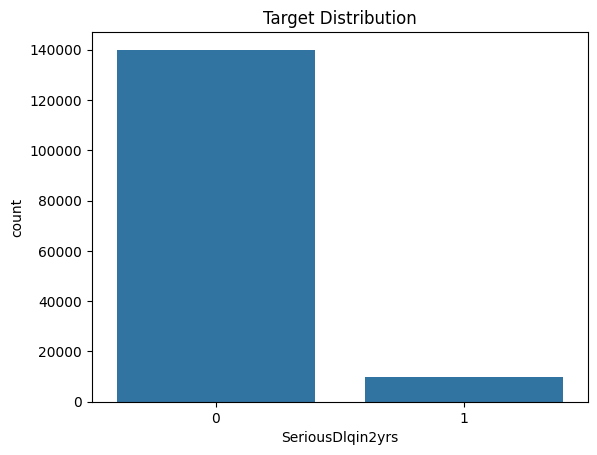

In [46]:
sns.countplot(x='SeriousDlqin2yrs', data=creditdata)
plt.title("Target Distribution")
plt.show()

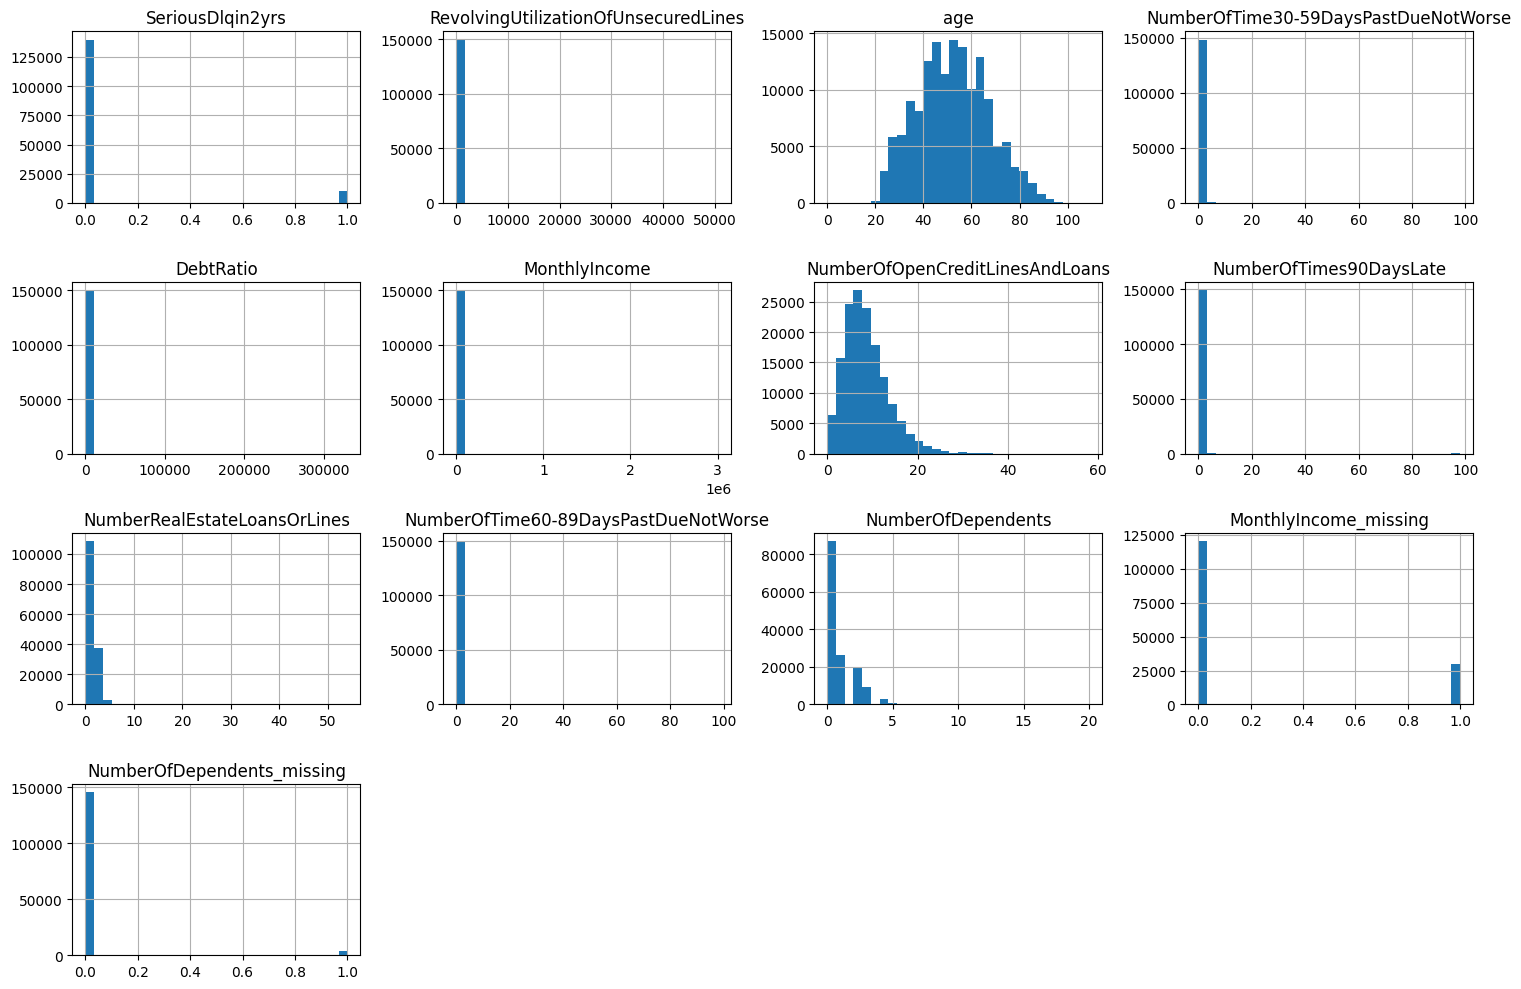

In [47]:
creditdata.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

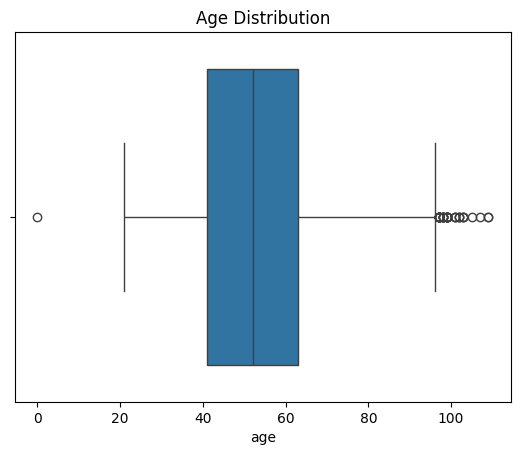

In [48]:
sns.boxplot(x=creditdata['age'])
plt.title("Age Distribution")
plt.show()

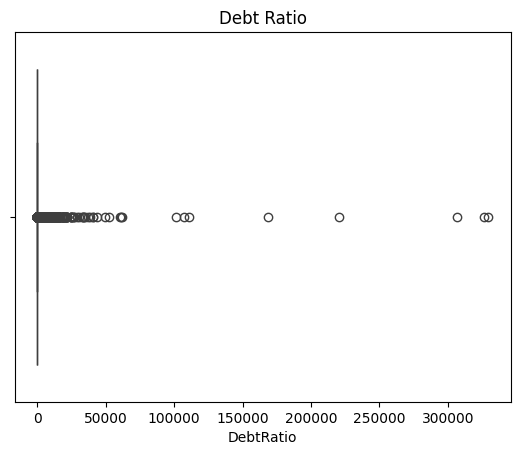

In [49]:
sns.boxplot(x=creditdata['DebtRatio'])
plt.title("Debt Ratio")
plt.show()

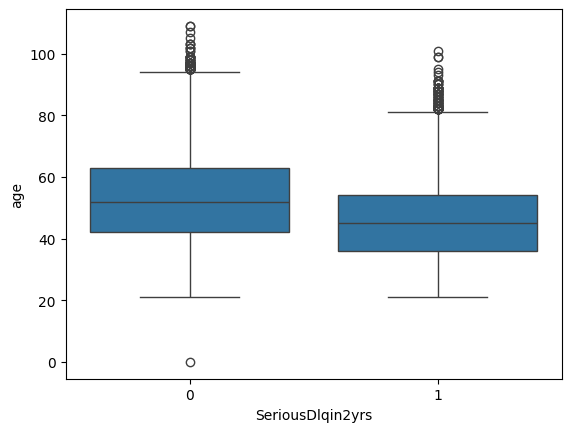

In [53]:
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=creditdata)
plt.show()

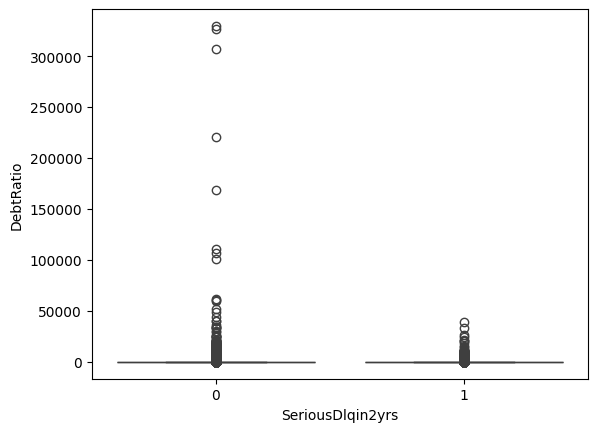

In [54]:
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', data=creditdata)
plt.show()

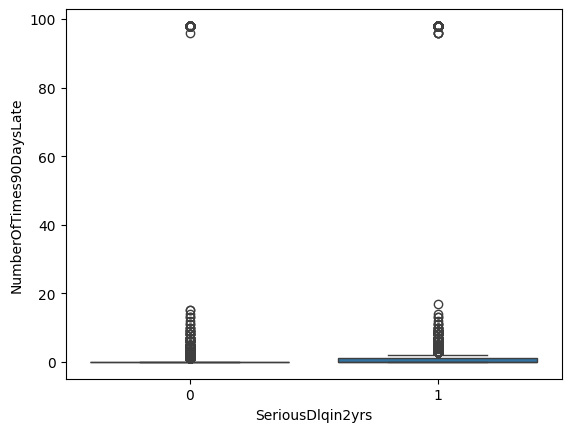

In [55]:
sns.boxplot(x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate', data=creditdata)
plt.show()

In [14]:
creditdata.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [15]:
creditdata['MonthlyIncome_missing'] = creditdata['MonthlyIncome'].isnull().astype(int)

In [16]:
creditdata['MonthlyIncome_missing'].head()

,MonthlyIncome_missing
0,0
1,0
2,0
3,0
4,0


In [17]:
creditdata[creditdata['NumberOfDependents'].isna()]


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN,1
96,97,0,0.542243,48,2,10.0,NaN,2,0,0,0,NaN,1
109,110,0,0.041258,61,0,4739.0,NaN,11,0,4,0,NaN,1
159,160,0,0.000000,63,0,2.0,NaN,4,0,0,0,NaN,1
238,239,0,1.000000,28,0,0.0,NaN,0,0,0,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149826,149827,0,0.027319,71,0,1419.0,NaN,13,0,1,0,NaN,1
149854,149855,0,0.056589,75,0,8.0,NaN,3,0,0,0,NaN,1
149894,149895,0,0.017904,55,0,1058.0,NaN,8,0,1,1,NaN,1
149948,149949,0,0.055530,27,0,10.0,NaN,1,0,0,0,NaN,1


In [18]:
creditdata.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
MonthlyIncome_missing,
0,0.069486
1,0.056137


<Axes: xlabel='MonthlyIncome_missing', ylabel='DebtRatio'>

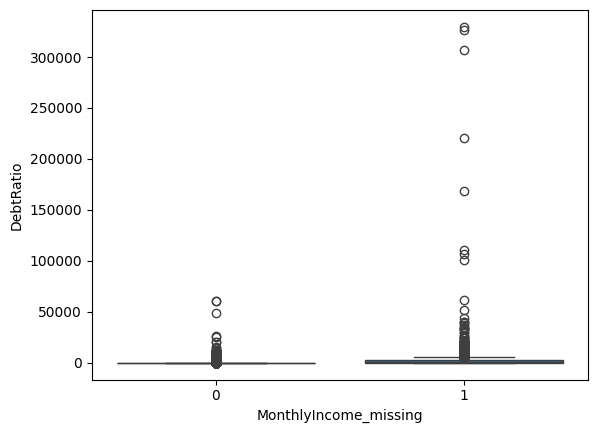

In [19]:
import seaborn as sns
sns.boxplot(x='MonthlyIncome_missing', y='DebtRatio', data=creditdata)

In [20]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(creditdata['MonthlyIncome_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 67.89295377039625
P-value: 1.7261692959788902e-16


p_value << 0.05 that means there is statistically significant relationship between missing income and default risk.

In [21]:
creditdata['NumberOfDependents'].value_counts()

,count
NumberOfDependents,
0.0,86902
1.0,26316
2.0,19522
3.0,9483
4.0,2862
5.0,746
6.0,158
7.0,51
8.0,24


In [22]:
creditdata['NumberOfDependents_missing'] = creditdata['NumberOfDependents'].isnull().astype(int)

In [23]:
creditdata.groupby('NumberOfDependents_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
NumberOfDependents_missing,
0,0.067410
1,0.045617


In [24]:
contingency_table = pd.crosstab(creditdata['NumberOfDependents_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 28.750364797617962
P-value: 8.233441027500607e-08


The chi-square test shows a statistically significant association between missing values in NumberOfDependents and SeriousDlqin2yrs (p < 0.05). Applicants with missing dependents have a lower observed default rate, suggesting that missingness carries predictive information.

In [25]:
print('Skewness coeficient',creditdata['age'].skew())

Skewness coeficient 0.18899454512676198


In [26]:
if "Unnamed: 0" in creditdata.columns:
    creditdata = creditdata.drop(columns=["Unnamed: 0"])

In [27]:
creditdata.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0


EDA

In [28]:
creditdata.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing'],
      dtype='object')

In [29]:
import plotly.express as px
px.histogram(creditdata , x = 'age' ,  text_auto = '.1f' , title = 'age Range')

In [30]:
px.histogram(creditdata , x = 'MonthlyIncome' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [31]:
px.histogram(creditdata , x = 'NumberRealEstateLoansOrLines' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [32]:
px.histogram(creditdata , x = 'SeriousDlqin2yrs' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [33]:
px.histogram(creditdata , x = 'NumberOfTime30-59DaysPastDueNotWorse' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [34]:
creditdata["age_bin"] = pd.cut(creditdata["age"], bins=[20,30,40,50,60,70,100])

creditdata.groupby("age_bin")["SeriousDlqin2yrs"].mean()



/tmp/ipykernel_40534/1677721344.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,SeriousDlqin2yrs
age_bin,
"(20, 30]",0.115646
"(30, 40]",0.098196
"(40, 50]",0.082570
"(50, 60]",0.061742
"(60, 70]",0.034714
"(70, 100]",0.022527


In [35]:
y = creditdata['SeriousDlqin2yrs']
X = creditdata.drop(columns = ['SeriousDlqin2yrs'])

This project compares various classification algorithms to identify the most effective model for predicting customer creditworthiness and minimizing default risk.

In [36]:
from sklearn.ensemble import RandomForestRegressor

features_for_impute = [
    'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents', 'RevolvingUtilizationOfUnsecuredLines'
]
train_income = creditdata[creditdata['MonthlyIncome'].notna()]
test_income = creditdata[creditdata['MonthlyIncome'].isna()]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_income[features_for_impute], train_income['MonthlyIncome'])

predicted_income = rf.predict(test_income[features_for_impute])

creditdata.loc[creditdata['MonthlyIncome'].isnull(), 'MonthlyIncome'] = predicted_income

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

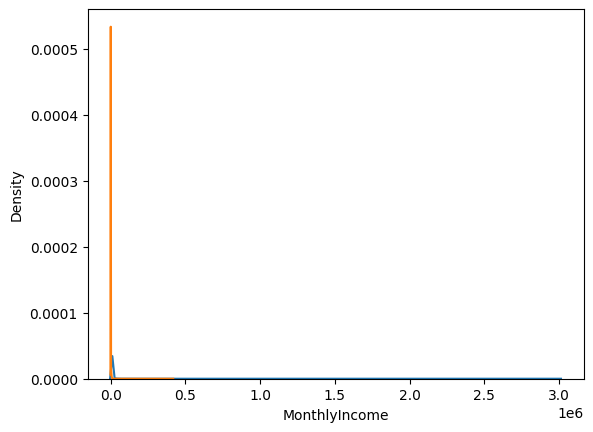

In [37]:
# Compare distributions
sns.kdeplot(train_income['MonthlyIncome'], label='Original')
sns.kdeplot(predicted_income, label='Imputed')

I used Random Forest for imputing MonthlyIncome because it captures non-linear relationships between financial features, is robust to outliers, and requires minimal preprocessing. Since the goal was to generate realistic values rather than perfectly predict income, it provided a strong and stable solution.

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

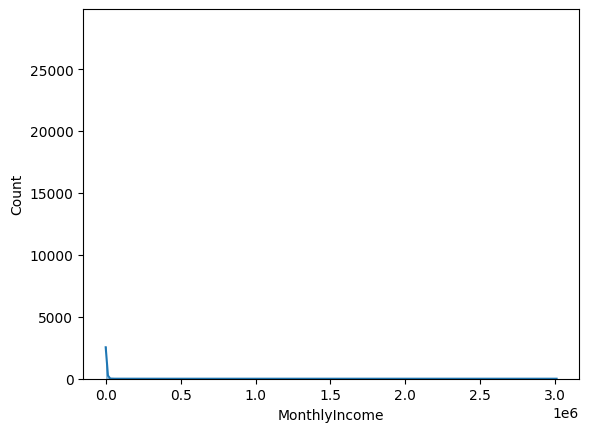

In [38]:
sns.histplot(creditdata['MonthlyIncome'], kde=True)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



<Axes: xlabel='MonthlyIncome', ylabel='Count'>

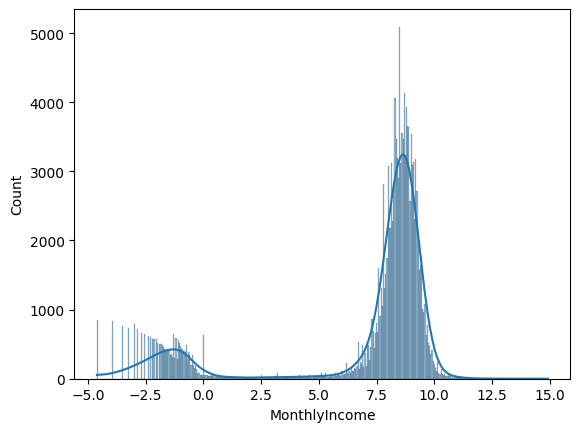

In [39]:
sns.histplot(np.log(creditdata['MonthlyIncome']), kde=True)

In [40]:
creditdata['MonthlyIncome'].skew()

np.float64(116.93869072211099)

In [41]:
np.log1p(creditdata['MonthlyIncome']).skew()

np.float64(-1.4773223164932316)